In [8]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr
import arviz as az
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
#jax.config.update("jax_enable_x64", True)

num_dimensions = 50
num_data = 100
noise_magnitude_on_each_point = 0.1
total_length = 1
def matern_32(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def rbf_kernel(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * jnp.exp(-1/2 * (r/scale)**2)
    return jnp.where(r > 0, result, result * (1.0 + jitter))


def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_dimensions - 1)

fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
shape = (num_dimensions, num_dimensions)
dist_matrix = jnp.fromfunction(dist_function, shape)

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
def cov_kernel(logscale):
    return rbf_kernel(dist_matrix, logscale)
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)


#observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)
#R = jnp.zeros((num_data, num_dimensions));
#R = R.at[jnp.arange(num_data), observed_indices].set(1);
R = jax.jacobian(response)(fixed_points_linspace)

def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    L2 = jnp.linalg.cholesky(cov2)
    
    # logdet via Cholesky: logdet(cov2) = 2 * sum(log(diag(L2)))
    logabsdet2 = 2.0 * jnp.sum(jnp.log(jnp.diag(L2)))
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    
    # trace(cov2^-1 @ cov1) via triangular solves instead of full solve
    solve1 = jax.scipy.linalg.cho_solve((L2, True), cov1)
    trace_term = jnp.trace(solve1)
    
    # mahalanobis term via triangular solve
    diff = x2 - x1
    y = jax.scipy.linalg.solve_triangular(L2, diff, lower=True)
    mahalanobis = jnp.sum(y**2)  # equivalent to y.T @ y, avoids the solve
    
    return 0.5 * (logabsdet2 - logabsdet1 - num_dimensions
                  + trace_term + mahalanobis)


In [9]:
def logscaleprior(logscale):
    return -0.5*logscale**2

In [10]:
num_overall_steps = 10000
burn_in = 100
def negative_logdensity(x):
    field_values = x[1:]
    logscale = x[0]
    cov_prior = cov_kernel(logscale)
    # L_K = jnp.linalg.cholesky(cov_prior)
    # R_enhanced = R @ L_K
    negative_log_p_d_given_s_and_scale = 0.5*(y_obs - R @ field_values).T @ inv_cov_data_matrix @ (y_obs - R @ field_values) 
    negative_log_p_s_given_scale = 0.5*field_values.T @ jnp.linalg.solve(cov_prior, field_values)
    negative_log_p_scale = -logscaleprior(logscale)
    _, logdet = jnp.linalg.slogdet(cov_prior)
    return negative_log_p_d_given_s_and_scale + negative_log_p_s_given_scale + negative_log_p_scale + 0.5*logdet

sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=10,
    step_size=0.2,
    inv_mass_matrix = jnp.array(np.load('correlated_scale_cov_matrix.npy')),
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(2)
initial_coordinates = jnp.zeros(num_dimensions + 1)
initial_coordinates = initial_coordinates.at[0].set(-2.5)

overall_position_arr_plus_scales, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logscales = overall_position_arr_plus_scales[:, 0]
overall_position_arr = overall_position_arr_plus_scales[:, 1:]  

Comparision of scale variance between HMC and analytical samples: 0.005331276450306177 vs 0.0052247862331569195
KL divergence between HMC samples and analytical posterior samples per dimension: 0.11362814158201218
ESS for parameter 0: 574.7449010989717


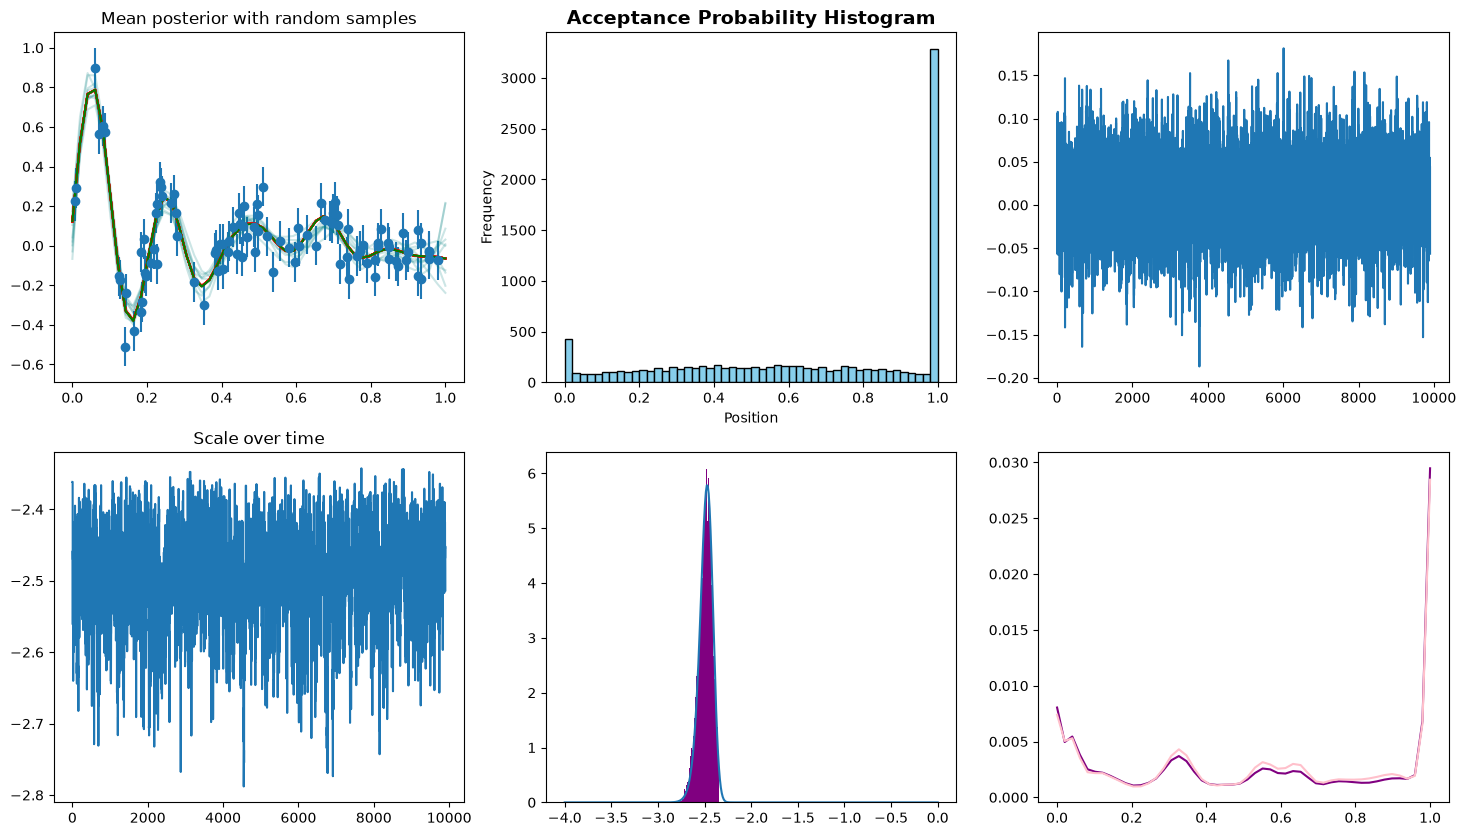

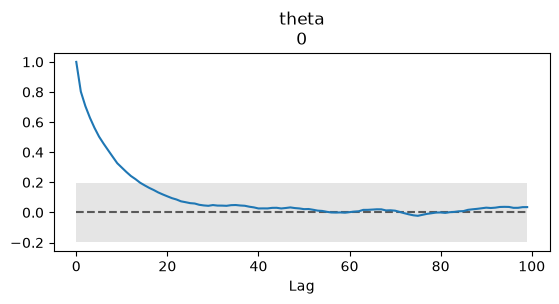

In [11]:
logscale_grid = jnp.linspace(-4, 0, 400)

def log_p_scale_given_data(logscale):
    cov_prior = cov_kernel(logscale)
    L_K = jnp.linalg.cholesky(cov_prior)
    R_white_to_correlated = R @ L_K
    cov_on_data_given_scale = R_white_to_correlated @ R_white_to_correlated.T + cov_data_matrix
    _, logdet = jnp.linalg.slogdet(cov_on_data_given_scale)
    return -0.5*y_obs @ jnp.linalg.solve(cov_on_data_given_scale, y_obs) - 0.5*logdet + logscaleprior(logscale) - 100
    #return logscaleprior(logscale)
    #return -0.5*y_obs @ jnp.linalg.solve(cov_on_data_given_scale, y_obs)
    #return 0.5*logdet
    
def draw_sample(noise, logscale):
    cov_prior = cov_kernel(logscale)
    D_inv = jnp.linalg.inv(cov_prior) + R.T @ jnp.linalg.solve(cov_data_matrix, R)
    M = jnp.linalg.solve(D_inv, R.T) @ jnp.linalg.inv(cov_data_matrix) @ y_obs
    L_D_inv = jnp.linalg.cholesky(D_inv)
    return jnp.linalg.solve(L_D_inv.T, noise) + M

num_samples = 1000
posterior = jnp.exp(jax.vmap(log_p_scale_given_data)(logscale_grid))
rng, k1, k2 = jr.split(rng, 3)
logscale_samples = jr.choice(k1, logscale_grid, p=posterior, shape=(num_samples,))
noise = jr.normal(k2, (num_samples, num_dimensions))
samples = jax.vmap(draw_sample)(noise, logscale_samples)
mean_sample = jnp.mean(samples, axis = 0)
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
mean_position = overall_position_arr.sum(axis=0)/num_good_samples
axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')

for i in range (0, 10):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[100*i, :], color = "teal", alpha = 0.2);
    axes[0][0].plot(fixed_points_linspace, mean_sample, color = "red", alpha = 1)
axes[0][0].plot(fixed_points_linspace, mean_position, color = "green", alpha = 1)
axes[0][0].set_title("Mean posterior with random samples")

axes[0][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[0][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[0][1].set_xlabel('Position')
axes[0][1].set_ylabel('Frequency')

axes[0][2].plot(time_arr, overall_position_arr[:, 30])
axes[1][0].set_title("Scale over time")
axes[1][0].plot(time_arr, logscales)

area_under_curve = np.trapezoid(posterior, logscale_grid)
normalized_posterior = posterior / area_under_curve
axes[1][1].plot(logscale_grid, normalized_posterior)
axes[1][1].hist(logscales, bins = 50, color = "purple", density = True)
cov_correlated_HMC_samples = jnp.cov(overall_position_arr, rowvar = False)
cov_analytical_samples = jnp.cov(samples, rowvar = False)
axes[1][2].plot(fixed_points_linspace, jnp.diag(cov_correlated_HMC_samples), color = "purple")
axes[1][2].plot(fixed_points_linspace, jnp.diag(cov_analytical_samples), color = "pink")
var_analytical_scale_samples = jnp.var(logscale_samples)
var_HMC_scale_samples = jnp.var(logscales)
print(f"Comparision of scale variance between HMC and analytical samples: {var_HMC_scale_samples} vs {var_analytical_scale_samples}")
KL_div = KL_div_between_two_Gaussians(mean_sample, cov_analytical_samples, mean_position, cov_correlated_HMC_samples, num_dimensions)/num_dimensions
print(f"KL divergence between HMC samples and analytical posterior samples per dimension: {KL_div}")

posterior_samples = overall_position_arr_plus_scales[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for parameter {param_index}: {ess_param}")

In [12]:
#cov_matrix_with_scale = jnp.cov(overall_position_arr_plus_scales, rowvar = False)
#print(cov_matrix_with_scale)
#np.save('correlated_scale_cov_matrix.npy', cov_matrix_with_scale)

In [13]:
def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)

